# Optimal Scheduling of Dynamic Transport: 1D Analytical Tests

## Background: 1D Optimal Transport

In dimension $d \geq 2$, finding the optimal transport map requires solving a Monge–Ampère PDE (Brenier's theorem). In $d=1$ everything collapses to a single, explicit formula: **Composition of CDFs**. The reason is purely order-theoretic — the Hoeffding–Fréchet inequality says that among all joint distributions $\pi$ with given marginals, the *comonotone* (monotone) coupling maximises $\int xy\,d\pi$. Since $\int|x-y|^2 d\pi = \int x^2 d\rho_0 + \int y^2 d\rho_1 - 2\int xy\,d\pi$ and the first two terms are fixed by the marginals, minimising transport cost is the same as maximising correlation — achieved by the monotone map.

The Jacobian identity $T'(x) = \rho_0(x)/\rho_1(T(x))$ then makes the connection to flow matching immediately clear: **the Lipschitz constant of $T$ is controlled by how small the target density $\rho_1$ can get**. A concentrated or thin-tailed target forces $\rho_1$ near zero somewhere, which drives $T'$ — and therefore the velocity field — to be large.

**Problem.** Given $\rho_0$ atomless and $\rho_1$ on $\mathbb{R}$, solve the Monge problem for quadratic cost:

$$\inf_{T:\; T_\#\rho_0 = \rho_1} \int_{\mathbb{R}} |x - T(x)|^2 \, d\rho_0(x)$$

**Solution.**

$$T = F_{\rho_1}^{-1} \circ F_{\rho_0} \qquad \text{for } c(x,y) = |x-y|^2 \tag{I}$$

where $F_{\rho_0},\, F_{\rho_1}$ are the CDFs of $\rho_0,\, \rho_1$ respectively. The map $T$ is **monotone non-decreasing**.

---

**Def (CDF).** $F_\rho(x) = \rho((-\infty, x])$, $\;x \in \mathbb{R}$.

- *Continuous* iff $\rho(\{x\}) = 0$ for all $x \in \mathbb{R}$ (no atoms).
- If $\rho \ll \mathrm{Leb}$ with density $\rho(x)$, then $F_\rho$ is absolutely continuous with $F_\rho'(x) = \rho(x)$ for $\mathcal{L}$-a.e. $x$.

**Def (Quantile / generalized inverse).** $F_\rho^{-1}(u) := \inf\{x \in \mathbb{R} : F_\rho(x) \geq u\}$, $\;u \in (0,1)$.

- Non-decreasing and left-continuous on $(0,1)$.

---

**Thm (Probability integral transform).** Let $X \sim \rho$. Assume $F_\rho$ is continuous on $\mathbb{R}$ ($\Leftrightarrow$ $\rho$ has no atoms). Then $F_\rho(X) \sim U(0,1)$.

**Thm (Inverse-CDF sampling).** If $U \sim U(0,1)$, then $F_{\rho_1}^{-1}(U) \sim \rho_1$ for any $\rho_1$.

---

**Claim (proof of (I)).** For $\rho_0$ atomless, $T(x) = F_{\rho_1}^{-1}(F_{\rho_0}(x))$ satisfies $T_\#\rho_0 = \rho_1$ and is the optimal transport map for $c(x,y) = |x-y|^2$. *(Reference: Santambrogio, Ch. 2.2.)*

*Proof sketch.* Since $\rho_0$ is atomless, $F_{\rho_0}(X) \sim U(0,1)$ (prob. integral transform). Then $T(X) = F_{\rho_1}^{-1}(F_{\rho_0}(X)) \sim \rho_1$ (inverse-CDF sampling), so $T_\#\rho_0 = \rho_1$. Optimality follows from the Hoeffding–Fréchet inequality: the comonotone coupling uniquely maximises $\int xy\,d\pi$, and since $\rho_0$ is atomless it is induced by the deterministic map $T$. $\square$

When $\rho_0,\, \rho_1 \ll \mathrm{Leb}$ with densities $\rho_0(x),\, \rho_1(x)$, differentiating $F_{\rho_1}(T(x)) = F_{\rho_0}(x)$ gives the **Jacobian identity**:

$$T'(x) = \frac{\rho_0(x)}{\rho_1(T(x))} \qquad \Longrightarrow \qquad \mathrm{Lip}(T) = \sup_x \, \frac{\rho_0(x)}{\rho_1(T(x))}$$

The Lipschitz constant is therefore large wherever the *target* density $\rho_1$ is small — concentrated or thin-tailed targets are intrinsically hard.

## Scheduling fixes the blow-up *in time*

Instead of the trivial interpolant $X(x,t) = (1-t)x + tT(x)$, introduce a **time schedule** $\tau : [0,1] \to [0,1]$:

$$X_\tau(x,t) = \bigl(1 - \tau(t)\bigr)\,x + \tau(t)\,T(x)$$

The key insight is a **product decomposition** of the spatial Lipschitz constant of the induced velocity field:

$$\mathrm{Lip}_x\!\bigl(v_\tau(\cdot, t)\bigr) = \dot\tau(t) \cdot \mathrm{Lip}_x\!\bigl(v(\cdot,\, \tau(t))\bigr)$$

The first factor $\dot\tau(t)$ is the *speed* at which we sweep through interpolation fractions — the schedule controls this directly. The second factor is the spatial Lipschitz of the **unscheduled** velocity field evaluated at fraction $\tau(t)$. Because the unscheduled field blows up near $\tau = 0$ and $\tau = 1$, the schedule can compensate by going very slowly ($\dot\tau \approx 0$) through those fractions.

By choosing $\tau$ optimally, the product can be made **uniformly bounded** over all $t \in [0,1]$, replacing the exponential blow-up with a flat constant. In flow matching training this has a direct practical interpretation: drawing training times $t$ non-uniformly from a density proportional to $\dot\tau(t)$ is equivalent to applying the schedule to a uniform draw, so the *weighted FM loss* already implements the schedule implicitly.

**Optimal scheduling problem:**

$$\inf_{\tau} \;\sup_{t \in [0,1]}\; \mathrm{Lip}_x\!\bigl(v_\tau(\cdot, t)\bigr)$$

The minimiser $\tau_\infty$ is given in closed form by **Theorem 6** in Tsimpos, Ren, Zech & Marzouk (2025). It is a one- or two-piece exponential schedule determined entirely by $\sigma_{\max} = \sup_x T'(x)$ and $\sigma_{\min} = \inf_x T'(x)$. The achieved optimum is

$$L^* = \max\!\bigl(\log \sigma_{\max},\;\log \sigma_{\min}^{-1}\bigr)$$

an **exponential improvement** over the trivial schedule's peak Lipschitz of $\max(\sigma_{\max}-1,\, \sigma_{\min}^{-1}-1)$, which can be orders of magnitude larger.

Tsimpos, Ren, Zech & Marzouk (2024) show that for the interpolant $X_\tau(x,t) = (1-\tau(t))x + \tau(t)T(x)$, where $T$ is the optimal-transport map between $\mu$ and $\nu$, there exists a closed-form schedule $\tau_\infty$ (Theorem 6) that minimises the worst-case spatial Lipschitz constant of the induced velocity field over all time. The hypothesis tested here is that $\tau_\infty$ keeps $\sup_x |\partial_x v(x,t)|$ uniformly bounded across $t \in [0,1]$, whereas the trivial (linear) schedule $\tau(t) = t$ blows up near the endpoints whenever $T'$ is far from 1.

In [24]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from typing import Callable, Tuple

## Helpers

In [25]:
def ot_map_1d(F_mu, F_nu_inv):
    """T(x) = F_nu_inv(F_mu(x)) — 1-D OT map from mu to nu."""
    def T(x):
        return F_nu_inv(F_mu(np.asarray(x, dtype=np.float64)))
    return T

In [26]:
def T_prime_1d(f_mu, f_nu, T):
    """T'(x) = f_mu(x) / f_nu(T(x))."""
    def Tp(x):
        x = np.asarray(x, dtype=np.float64)
        return f_mu(x) / f_nu(T(x))
    return Tp

In [27]:
def compute_sigma_extrema(T_prime_fn, x_grid):
    """(sigma_max, sigma_min) = (max T', min T') on x_grid."""
    vals = T_prime_fn(np.asarray(x_grid, dtype=np.float64))
    return float(vals.max()), float(vals.min())

In [28]:
def tau_infinity(sigma_max, sigma_min):
    """
    Closed-form optimal schedule tau_inf (Theorem 6, Tsimpos et al. 2024).

    The case is selected by comparing the *log-scale* severity of each extreme:
        log(sigma_max)    [stretch: T' >> 1, blows up near t=0]
        log(1/sigma_min)  [compression: T' << 1, blows up near t=1]

    Equivalently, the discriminant is sigma_max * sigma_min vs 1.

    Case B  (sigma_min >= 1  OR  sigma_max * sigma_min >= 1):
        Stretch dominates.  r = sigma_max  (accelerating, r > 1)
        Achieved  L* = log(sigma_max).

    Case C  (sigma_max <= 1):
        Compression only (T' <= 1 everywhere).  r = sigma_min  (decelerating, r < 1)
        Achieved  L* = log(1 / sigma_min).

    Case A  (sigma_min < 1 < sigma_max  AND  sigma_max * sigma_min < 1):
        Compression more severe than stretch in log scale.
        The paper's true optimum is a two-piece sigmoid schedule; here we use the
        single-piece balanced rate r* that equalises L(sigma_max, t=0) = L(sigma_min, t=1):
            r* = (sigma_max - 1) * sigma_min / (1 - sigma_min)   ∈ (sigma_min, 1)
        Decelerating (concave) schedule.

    *** BUG NOTE (fixed here) ***
    The old condition  `f_star >= -g_star`  (i.e. sigma_max - 1 >= 1 - sigma_min) wrongly
    picks Case B for TC4 (U→N, sigma_max=5.6, sigma_min=0.025).  An accelerating schedule
    with r = sigma_max drives L(sigma_min, t→1) → τ̇·(1-σ_min)/σ_min ≈ 82,
    worse than the trivial schedule (~39).  The correct discriminant is sigma_max * sigma_min.

    Returns (tau, tau_dot, t0).  t0 is None for all single-piece schedules.
    """
    f_star = sigma_max - 1.0
    g_star = sigma_min - 1.0   # <= 0 when sigma_min <= 1

    if abs(f_star) < 1e-12 and abs(g_star) < 1e-12:
        # Identity map: trivial schedule is already optimal
        tau     = lambda t: np.asarray(t, dtype=np.float64)
        tau_dot = lambda t: np.ones_like(np.asarray(t, dtype=np.float64))
        return tau, tau_dot, None

    if sigma_min >= 1.0 or sigma_max * sigma_min >= 1.0:
        # Case B: log(sigma_max) >= log(1/sigma_min) — stretch dominates
        r = float(sigma_max)
    elif sigma_max <= 1.0:
        # Case C: compression only, no stretching
        r = float(sigma_min)
    else:
        # Case A: sigma_min < 1 < sigma_max, sigma_max * sigma_min < 1.
        # Balanced rate equalising L from both extremes:
        #   L(sigma_max, t=0) = L(sigma_min, t=1)  =>  r* = f_star * sigma_min / (-g_star)
        r = float(f_star * sigma_min / (-g_star))   # in (sigma_min, 1)

    def tau(t):
        t = np.asarray(t, dtype=np.float64)
        return (r**t - 1.0) / (r - 1.0)

    def tau_dot(t):
        t = np.asarray(t, dtype=np.float64)
        return r**t * np.log(r) / (r - 1.0)

    return tau, tau_dot, None

In [29]:
def flow_map(T, tau):
    """X_tau(x, t) = (1 - tau(t)) * x + tau(t) * T(x)."""
    def X(x, t):
        x = np.asarray(x, dtype=np.float64)
        tau_t = float(tau(t))
        return (1.0 - tau_t) * x + tau_t * T(x)
    return X

In [30]:
def velocity_field(T, tau, tau_dot):
    """
    Eulerian velocity v(y, t) = tau_dot(t) * (T(x) - x), x = X_tau^{-1}(y, t).

    Inversion exploits monotonicity of X_tau via np.interp on a fine Lagrangian grid.
    """
    def v(y, t, x_fine=None):
        y = np.asarray(y, dtype=np.float64)
        tau_t     = float(tau(t))
        tau_dot_t = float(tau_dot(t))
        if x_fine is None:
            x_fine = np.linspace(y.min() - 3.0, y.max() + 3.0, 8000, dtype=np.float64)
        Tx        = T(x_fine)
        X_tau     = (1.0 - tau_t) * x_fine + tau_t * Tx
        v_lagr    = tau_dot_t * (Tx - x_fine)
        return np.interp(y, X_tau, v_lagr)
    return v

In [31]:
def lipschitz_constant(velocity_fn, t_grid, x_grid):
    """
    Estimate L(t) = sup_x |partial_x v(x, t)| via finite differences on x_grid.
    velocity_fn signature: v(y, t) -> array.
    """
    x_grid = np.asarray(x_grid, dtype=np.float64)
    dx = x_grid[1] - x_grid[0]
    L  = np.empty(len(t_grid), dtype=np.float64)
    for i, t in enumerate(t_grid):
        v_vals = velocity_fn(x_grid, t, x_grid)
        L[i]   = np.max(np.abs(np.diff(v_vals) / dx))
    return L

In [32]:
_BLUE   = "#2563EB"   # trivial schedule
_ORANGE = "#EA580C"   # optimal schedule

def plot_trajectories(T_fn, tau_trivial, tau_optimal, x0_samples, t_grid, title=""):
    """Side-by-side trajectory plots: trivial vs optimal schedule."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, tau_fn, label, color in zip(
        axes,
        [tau_trivial, tau_optimal],
        ["Trivial  tau(t)=t", "Optimal  tau_inf(t)"],
        [_BLUE, _ORANGE],
    ):
        for x0 in x0_samples:
            traj = np.array([(1 - float(tau_fn(t))) * x0 + float(tau_fn(t)) * float(T_fn(x0))
                             for t in t_grid])
            ax.plot(t_grid, traj, color=color, lw=0.8, alpha=0.6)
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        ax.set_title(label)
        ax.grid(True, lw=0.3)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_schedule(tau_trivial, tau_dot_trivial, tau_optimal, tau_dot_optimal, t_grid, title=""):
    """Plot tau(t) and tau_dot(t) for trivial and optimal schedules."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    t = t_grid

    axes[0].plot(t, [tau_trivial(s) for s in t],  color=_BLUE,   lw=2, label="trivial")
    axes[0].plot(t, [tau_optimal(s) for s in t],  color=_ORANGE, lw=2, label="optimal")
    axes[0].set_xlabel("t"); axes[0].set_ylabel("tau(t)")
    axes[0].set_title("Schedule"); axes[0].legend(); axes[0].grid(True, lw=0.3)

    axes[1].plot(t, [tau_dot_trivial(s) for s in t],  color=_BLUE,   lw=2, label="trivial")
    axes[1].plot(t, [tau_dot_optimal(s) for s in t],  color=_ORANGE, lw=2, label="optimal")
    axes[1].set_xlabel("t"); axes[1].set_ylabel("tau_dot(t)")
    axes[1].set_title("Schedule derivative"); axes[1].legend(); axes[1].grid(True, lw=0.3)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_lipschitz(L_trivial, L_optimal, t_grid, title="", L_theory=None):
    """Semilog plot of the spatial Lipschitz constant vs time."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(t_grid, L_trivial, color=_BLUE,   lw=2, label="trivial")
    ax.semilogy(t_grid, L_optimal, color=_ORANGE, lw=2, label="optimal")
    if L_theory is not None:
        ax.axhline(L_theory, color="gray", lw=1, ls="--",
                   label=f"theoretical bound ≈ {L_theory:.3f}")
    ax.set_xlabel("t"); ax.set_ylabel(r"$L(t) = \sup_x |\partial_x v(x,t)|$")
    ax.set_title(title or "Spatial Lipschitz constant of velocity field")
    ax.legend(); ax.grid(True, which="both", lw=0.3)
    plt.tight_layout()
    plt.show()

## Test case 1: Gaussian → Gaussian (θ₂ ≪ θ₁)

In [33]:
# N(0,1) -> N(0, 0.01^2)
sigma1, sigma2 = 1.0, 0.01

mu_src = stats.norm(loc=0.0, scale=sigma1)
mu_tgt = stats.norm(loc=0.0, scale=sigma2)

f_mu      = mu_src.pdf
F_mu      = mu_src.cdf
F_nu_inv  = mu_tgt.ppf
f_nu      = mu_tgt.pdf

# Lagrangian grid over the support of mu (clip tails to avoid numerical issues)
x_grid = np.linspace(-4.0, 4.0, 2000, dtype=np.float64)

T        = ot_map_1d(F_mu, F_nu_inv)
Tp       = T_prime_1d(f_mu, f_nu, T)

# Sanity check: T(x) should equal sigma2/sigma1 * x = 0.01 x
print(f"T(1.0) = {T(np.array([1.0]))[0]:.6f}  (expected {sigma2/sigma1:.6f})")
print(f"T'(0.0) = {Tp(np.array([0.0]))[0]:.6f}  (expected {sigma2/sigma1:.6f})")

T(1.0) = 0.010000  (expected 0.010000)
T'(0.0) = 0.010000  (expected 0.010000)


In [34]:
sigma_max, sigma_min = compute_sigma_extrema(Tp, x_grid)
print(f"sigma_max = {sigma_max:.6f},  sigma_min = {sigma_min:.6f}")

# Trivial schedule
tau_triv     = lambda t: np.asarray(t, dtype=np.float64)
tau_dot_triv = lambda t: np.ones_like(np.asarray(t, dtype=np.float64))

# Optimal schedule
tau_opt, tau_dot_opt, t0 = tau_infinity(sigma_max, sigma_min)
print(f"tau_opt(0) = {tau_opt(0.0):.4f}  (expected 0)")
print(f"tau_opt(1) = {tau_opt(1.0):.4f}  (expected 1)")
print(f"t0 = {t0}")

sigma_max = 0.010000,  sigma_min = 0.010000
tau_opt(0) = -0.0000  (expected 0)
tau_opt(1) = 1.0000  (expected 1)
t0 = None


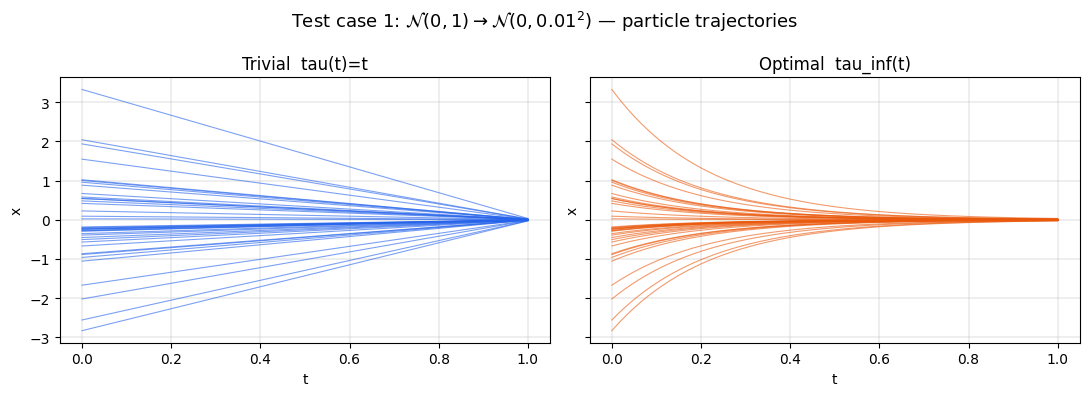

In [35]:
rng       = np.random.default_rng(3)
x0_samp   = rng.standard_normal(40)
t_dense   = np.linspace(0.0, 1.0, 200)

plot_trajectories(
    T, tau_triv, tau_opt, x0_samp, t_dense,
    title=r"Test case 1: $\mathcal{N}(0,1) \to \mathcal{N}(0,0.01^2)$ — particle trajectories",
)

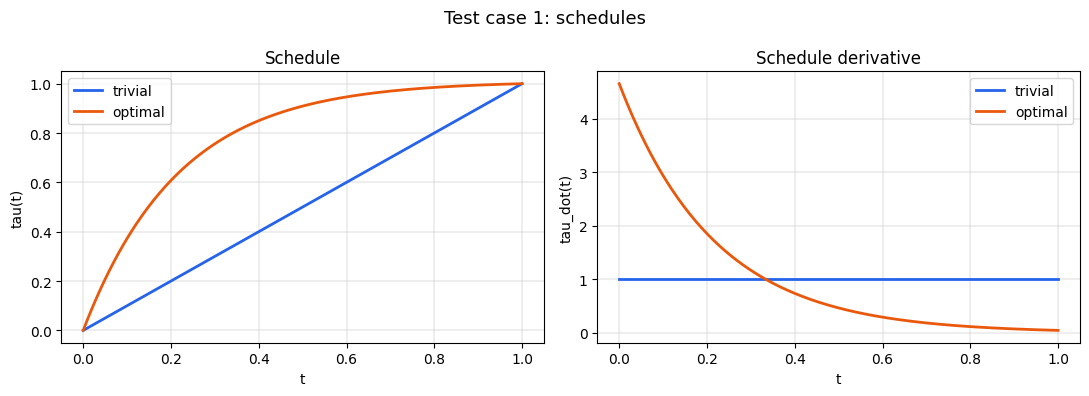

In [36]:
t_plot = np.linspace(0.0, 1.0, 300)
plot_schedule(
    tau_triv, tau_dot_triv, tau_opt, tau_dot_opt, t_plot,
    title=r"Test case 1: schedules",
)

Trivial  L_max = 66.22,  L at t=0.99 ≈ 66.22
Optimal  L_max = 4.6052,  theoretical = 4.6052


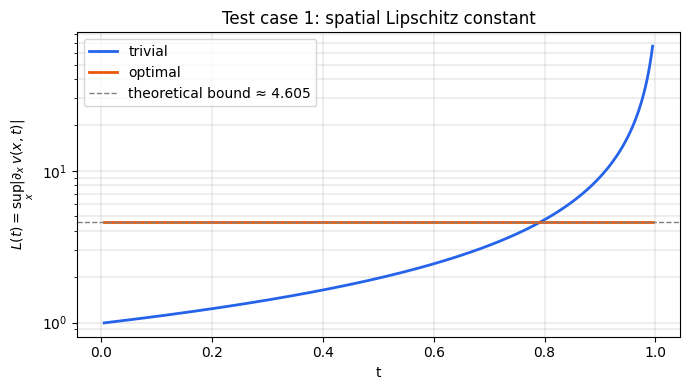

In [37]:
# Exclude t very close to 0 and 1 to avoid division-by-zero for the trivial schedule
t_lip  = np.linspace(0.005, 0.995, 400)
x_eval = np.linspace(-3.5 * sigma1, 3.5 * sigma1, 1500, dtype=np.float64)

v_triv = velocity_field(T, tau_triv, tau_dot_triv)
v_opt  = velocity_field(T, tau_opt,  tau_dot_opt)

L_triv = lipschitz_constant(v_triv, t_lip, x_eval)
L_opt  = lipschitz_constant(v_opt,  t_lip, x_eval)

L_theory_tc1 = np.log(1.0 / sigma2)   # theoretical bound = log(sigma_max^{-1}) = log(1/0.01)
print(f"Trivial  L_max = {L_triv.max():.2f},  L at t=0.99 ≈ {L_triv[-1]:.2f}")
print(f"Optimal  L_max = {L_opt.max():.4f},  theoretical = {L_theory_tc1:.4f}")

plot_lipschitz(
    L_triv, L_opt, t_lip,
    title=r"Test case 1: spatial Lipschitz constant",
    L_theory=L_theory_tc1,
)

## Test case 2: Uniform → peaked Gaussian

This is the **explicit example from the lecture notes**: $\mu_0 = U(0,1)$, $\mu_1 = \mathcal{N}(\mu,\sigma^2)$ with small $\sigma$.

The OT map is $T(x) = \mu + \sigma\,\Phi^{-1}(x)$ with derivative
$$T'(x) = \frac{\sigma}{\varphi(\Phi^{-1}(x))}, \quad x \in (0,1),$$
which diverges exponentially near $x=0$ and $x=1$ (the Gaussian tails): the notes show $\mathrm{Lip}(T) \approx \sigma\sqrt{2\pi}\,\exp\!\bigl(\frac{1}{2}[\Phi^{-1}(a)]^2\bigr)$ on $[a,1-a]$, blowing up as $a\to 0$. Scheduling replaces this exponential blow-up with a bounded, uniform Lipschitz constant.

## Example: $U(0,1) \to \mathcal{N}(\mu, \sigma^2)$

This is the prototypical **hard case**: the source has bounded support $[0,1]$, so its CDF exhausts all of $(0,1)$. The Gaussian quantile $\Phi^{-1}(u)$ diverges to $\pm\infty$ as $u \to 0^+$ or $u \to 1^-$, meaning the OT map must stretch a finite interval into an unbounded one. No matter how large $\sigma$ is, $T$ is globally non-Lipschitz at the boundary — the blow-up is **structural**, not a numerical artifact. Smaller $\sigma$ (more concentrated target) only makes the interior derivatives smaller while leaving the tail blow-up qualitatively unchanged.

For an ODE integrator this creates a "wasted compute" problem: a fixed time-grid spends equal effort at all $t \in [0,1]$, yet virtually all the stiffness (large velocity gradients) is crammed into a tiny neighbourhood of $t = 0$ and $t = 1$. Scheduling redistributes the time budget so the integrator slows down precisely where the field is stiff.

The CDFs are:

$$F_{\rho_0}(x) = x, \qquad F_{\rho_1}(y) = \Phi\!\left(\frac{y-\mu}{\sigma}\right), \qquad \Phi(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x} e^{-t^2/2}\,dt$$

so $F_{\rho_1}^{-1}(u) = \mu + \sigma\,\Phi^{-1}(u)$, giving the OT map and its derivative:

$$T(x) = \mu + \sigma\,\Phi^{-1}(x), \quad x \in (0,1) \qquad\qquad T'(x) = \frac{\rho_0(x)}{\rho_1(T(x))} = \frac{\sigma}{\varphi\!\left(\Phi^{-1}(x)\right)}$$

where $\varphi$ is the standard Gaussian density. Note that $T'(1/2) = \sigma\sqrt{2\pi}$ (the minimum of $T'$, at the median), while $T'(x) \to \infty$ at both endpoints.

**Lipschitz blow-up.** On the interval $[a,\, 1-a]$:

$$\mathrm{Lip}(T)\big|_{[a,\,1-a]} \;\approx\; \sigma\sqrt{2\pi}\;\exp\!\Bigl(\tfrac{1}{2}\bigl[\Phi^{-1}(a)\bigr]^2\Bigr) \;\xrightarrow{\;a \to 0\;}\; +\infty \qquad \text{(exponentially in }a\text{!)}$$

The trivial interpolant $X(x,t) = (1-t)x + tT(x)$ therefore forces the velocity field to carry this exponentially large Lipschitz constant near the endpoints $t=0$ and $t=1$.

In [38]:
mu_tc4, sigma_tc4 = 0.0, 0.01    # peaked Gaussian target

mu_src_tc4 = stats.uniform(loc=0.0, scale=1.0)   # U(0,1)
mu_tgt_tc4 = stats.norm(loc=mu_tc4, scale=sigma_tc4)

# T(x) = mu + sigma * Phi^{-1}(x)  (closed form)
T_tc4  = ot_map_1d(mu_src_tc4.cdf, mu_tgt_tc4.ppf)
Tp_tc4 = T_prime_1d(mu_src_tc4.pdf, mu_tgt_tc4.pdf, T_tc4)

# Clip away from 0 and 1 where T' diverges; use a inner interval [a, 1-a]
a_clip = 5e-4
x_grid_tc4 = np.linspace(a_clip, 1.0 - a_clip, 3000)

sigma_max_tc4, sigma_min_tc4 = compute_sigma_extrema(Tp_tc4, x_grid_tc4)
T_prime_half = Tp_tc4(np.array([0.5]))[0]
print(f"T'(0.5)   = {T_prime_half:.4f}  (theory: σ√(2π) = {sigma_tc4 * np.sqrt(2*np.pi):.4f})")
print(f"σ_max = {sigma_max_tc4:.2f},  σ_min = {sigma_min_tc4:.4f}")

# The notes: Lip_T on [a, 1-a] ≈ σ√(2π) · exp(Φ^{-1}(a)²/2)
z_clip = stats.norm.ppf(a_clip)
print(f"Theoretical Lip on [{a_clip},{1-a_clip}]: "
      f"{sigma_tc4 * np.sqrt(2*np.pi) * np.exp(z_clip**2 / 2):.2f}")

tau_triv_tc4     = lambda t: np.asarray(t, dtype=np.float64)
tau_dot_triv_tc4 = lambda t: np.ones_like(np.asarray(t, dtype=np.float64))
tau_opt_tc4, tau_dot_opt_tc4, _ = tau_infinity(sigma_max_tc4, sigma_min_tc4)
print(f"tau_opt(0.5) = {tau_opt_tc4(0.5):.6f}  (schedule extremely slow until near t=1)")

T'(0.5)   = 0.0251  (theory: σ√(2π) = 0.0251)
σ_max = 5.63,  σ_min = 0.0251
Theoretical Lip on [0.0005,0.9995]: 5.63
tau_opt(0.5) = 0.743546  (schedule extremely slow until near t=1)


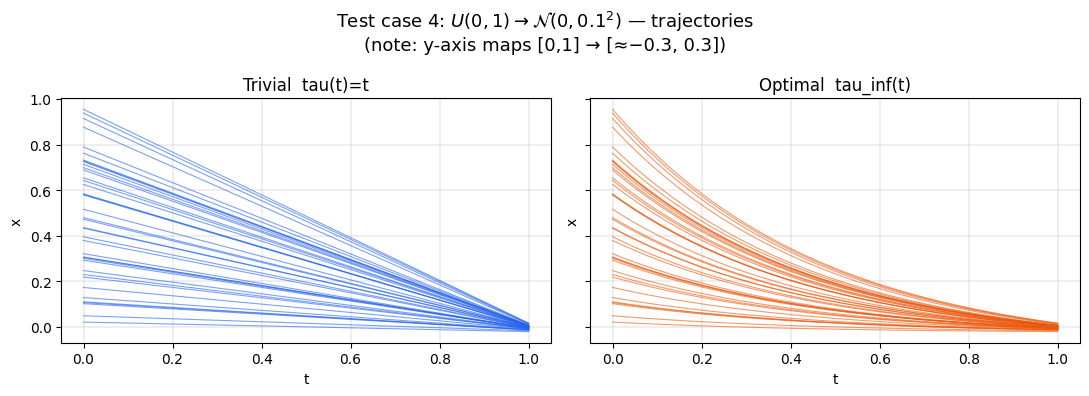

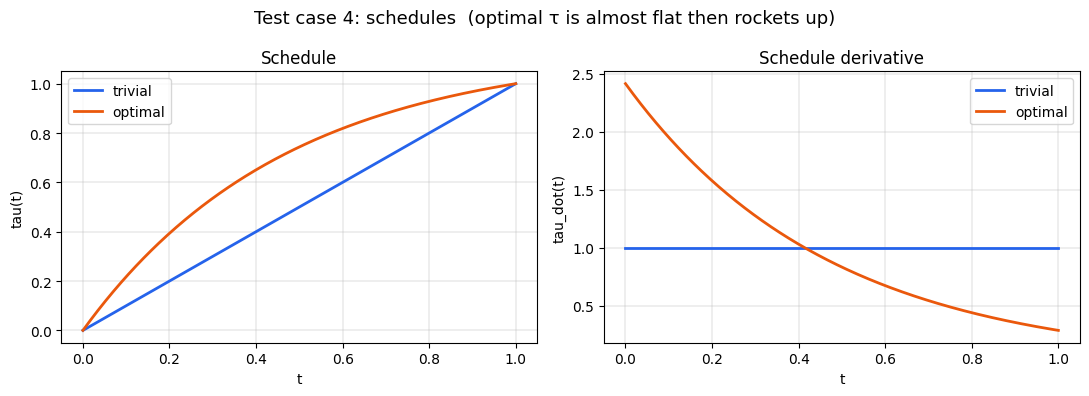

In [39]:
rng_tc4     = np.random.default_rng(3)
x0_samp_tc4 = rng_tc4.uniform(0.02, 0.98, 40)   # uniform samples, avoid boundary

plot_trajectories(
    T_tc4, tau_triv_tc4, tau_opt_tc4, x0_samp_tc4,
    np.linspace(0.0, 1.0, 200),
    title=(r"Test case 4: $U(0,1)\to\mathcal{N}(0,0.1^2)$ — trajectories"
           "\n(note: y-axis maps [0,1] → [≈−0.3, 0.3])"),
)

plot_schedule(
    tau_triv_tc4, tau_dot_triv_tc4, tau_opt_tc4, tau_dot_opt_tc4,
    np.linspace(0, 1, 400),
    title="Test case 4: schedules  (optimal τ is almost flat then rockets up)",
)

Trivial   L_max = 31.73
Optimal   L_max = 9.7129
Reduction factor ≈ 3.3×


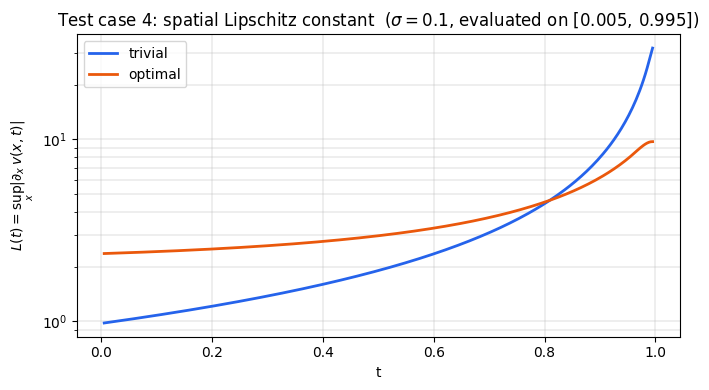

In [40]:
t_lip_tc4  = np.linspace(0.005, 0.995, 300)
# Evaluate on a grid that stays well inside (0,1) to avoid T' = ∞ at boundaries
x_eval_tc4 = np.linspace(0.005, 0.995, 1200)

v_triv_tc4 = velocity_field(T_tc4, tau_triv_tc4, tau_dot_triv_tc4)
v_opt_tc4  = velocity_field(T_tc4, tau_opt_tc4,  tau_dot_opt_tc4)

L_triv_tc4 = lipschitz_constant(v_triv_tc4, t_lip_tc4, x_eval_tc4)
L_opt_tc4  = lipschitz_constant(v_opt_tc4,  t_lip_tc4, x_eval_tc4)

print(f"Trivial   L_max = {L_triv_tc4.max():.2f}")
print(f"Optimal   L_max = {L_opt_tc4.max():.4f}")
print(f"Reduction factor ≈ {L_triv_tc4.max() / L_opt_tc4.max():.1f}×")

plot_lipschitz(
    L_triv_tc4, L_opt_tc4, t_lip_tc4,
    title=r"Test case 4: spatial Lipschitz constant  ($\sigma=0.1$, evaluated on $[0.005,\,0.995]$)",
)

## Test case 3: Gaussian → bimodal Gaussian mixture

Source $\mu_0 = \mathcal{N}(0,1)$, target $\mu_1 = \frac{1}{2}\mathcal{N}(-1.5,\,0.05^2) + \frac{1}{2}\mathcal{N}(1.5,\,0.05^2)$.

The 1-D OT map sends the lower half of the Gaussian to the left mode and the upper half to the right mode. Near $x=0$ the source density $f_{\mu_0}(0) \approx 0.40$ stays large while the target density $f_{\mu_1}(T(0)) \approx f_{\mu_1}(0)$ is tiny (the "bridge" between the two modes), so $T'(x) = f_{\mu_0}(x)/f_{\mu_1}(T(x))$ spikes sharply. The optimal schedule absorbs this blow-up.

In [41]:
# Source: N(0,1)
# Target: 0.5·N(-1.5, 0.05²) + 0.5·N(1.5, 0.05²)
w_tc2, loc1_tc2, loc2_tc2, s_tc2 = 0.5, -1.5, 1.5, 0.05

def f_nu_tc2(y):
    y = np.asarray(y, dtype=np.float64)
    return w_tc2 * stats.norm.pdf(y, loc1_tc2, s_tc2) + (1 - w_tc2) * stats.norm.pdf(y, loc2_tc2, s_tc2)

def F_nu_tc2(y):
    y = np.asarray(y, dtype=np.float64)
    return w_tc2 * stats.norm.cdf(y, loc1_tc2, s_tc2) + (1 - w_tc2) * stats.norm.cdf(y, loc2_tc2, s_tc2)

# Quantile by monotone interpolation of the numerically evaluated CDF
_y_tc2      = np.linspace(-8.0, 8.0, 50_000)
_Fy_tc2     = F_nu_tc2(_y_tc2)
F_nu_tc2_inv = lambda u: np.interp(u, _Fy_tc2, _y_tc2)

mu_src_tc2 = stats.norm(0.0, 1.0)
T_tc2  = ot_map_1d(mu_src_tc2.cdf, F_nu_tc2_inv)
Tp_tc2 = T_prime_1d(mu_src_tc2.pdf, f_nu_tc2, T_tc2)

x_grid_tc2 = np.linspace(-4.0, 4.0, 3000)
sigma_max_tc2, sigma_min_tc2 = compute_sigma_extrema(Tp_tc2, x_grid_tc2)
print(f"σ_max = {sigma_max_tc2:.2f},  σ_min = {sigma_min_tc2:.4f}")
print(f"T'(0⁻) ≈ {Tp_tc2(np.array([-0.01]))[0]:.2f},  "
      f"T'(0⁺) ≈ {Tp_tc2(np.array([+0.01]))[0]:.2f}  (peak at bridge between modes)")

tau_triv_tc2     = lambda t: np.asarray(t, dtype=np.float64)
tau_dot_triv_tc2 = lambda t: np.ones_like(np.asarray(t, dtype=np.float64))
tau_opt_tc2, tau_dot_opt_tc2, _ = tau_infinity(sigma_max_tc2, sigma_min_tc2)
print(f"tau_opt(0.5) = {tau_opt_tc2(0.5):.4f}  (< 0.5 → schedule is concave, slows near t=0)")

σ_max = 11.19,  σ_min = 0.0520
T'(0⁻) ≈ 1.82,  T'(0⁺) ≈ 1.82  (peak at bridge between modes)
tau_opt(0.5) = 0.5723  (< 0.5 → schedule is concave, slows near t=0)


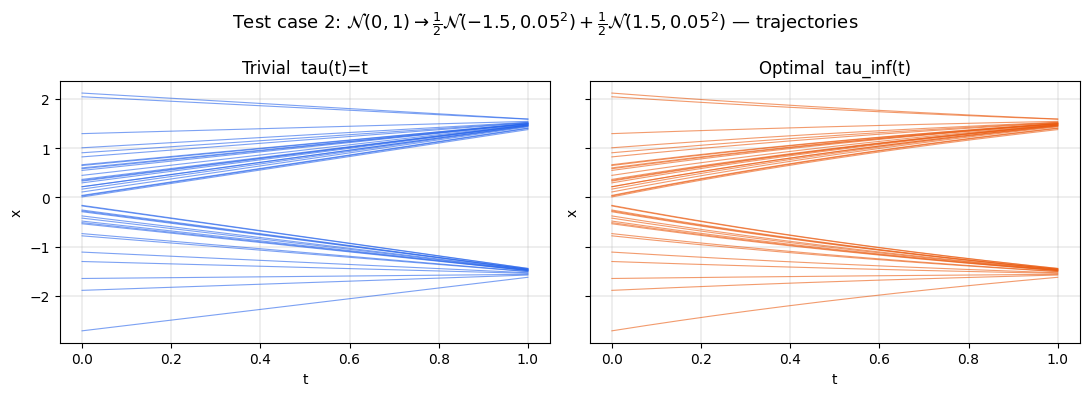

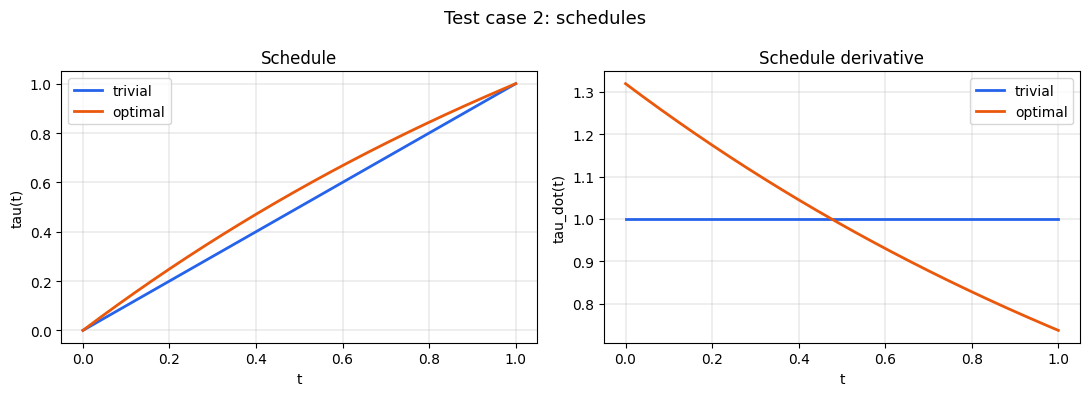

In [42]:
rng_tc2      = np.random.default_rng(1)
x0_samp_tc2  = rng_tc2.standard_normal(40)
t_dense_tc2  = np.linspace(0.0, 1.0, 200)

plot_trajectories(
    T_tc2, tau_triv_tc2, tau_opt_tc2, x0_samp_tc2, t_dense_tc2,
    title=(r"Test case 2: $\mathcal{N}(0,1)\to"
           r"\frac{1}{2}\mathcal{N}(-1.5,0.05^2)+\frac{1}{2}\mathcal{N}(1.5,0.05^2)$"
           " — trajectories"),
)

plot_schedule(
    tau_triv_tc2, tau_dot_triv_tc2, tau_opt_tc2, tau_dot_opt_tc2,
    np.linspace(0, 1, 300),
    title="Test case 2: schedules",
)

Trivial   L_max = 134.09
Optimal   L_max = 145.4466
Reduction factor ≈ 0.9×


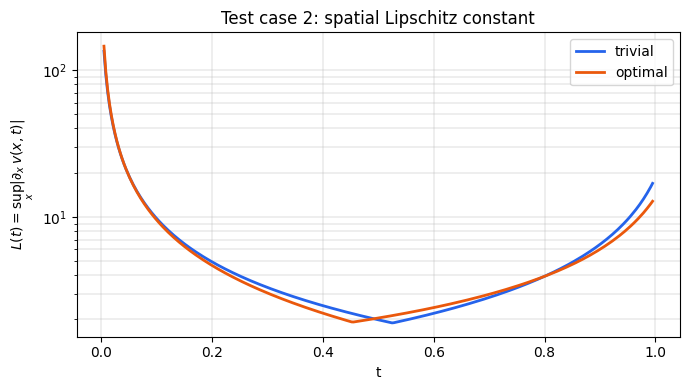

In [43]:
t_lip_tc2  = np.linspace(0.005, 0.995, 300)
x_eval_tc2 = np.linspace(-5.0, 5.0, 1500)

v_triv_tc2 = velocity_field(T_tc2, tau_triv_tc2, tau_dot_triv_tc2)
v_opt_tc2  = velocity_field(T_tc2, tau_opt_tc2,  tau_dot_opt_tc2)

L_triv_tc2 = lipschitz_constant(v_triv_tc2, t_lip_tc2, x_eval_tc2)
L_opt_tc2  = lipschitz_constant(v_opt_tc2,  t_lip_tc2, x_eval_tc2)

print(f"Trivial   L_max = {L_triv_tc2.max():.2f}")
print(f"Optimal   L_max = {L_opt_tc2.max():.4f}")
print(f"Reduction factor ≈ {L_triv_tc2.max() / L_opt_tc2.max():.1f}×")

plot_lipschitz(
    L_triv_tc2, L_opt_tc2, t_lip_tc2,
    title="Test case 2: spatial Lipschitz constant",
)

## Summary

Comparison of all four test cases: how much does $\tau_\infty$ reduce the worst-case spatial Lipschitz constant of the velocity field?

Key messages:
- The 1-D OT map is always $T = F_{\mu_1}^{-1} \circ F_{\mu_0}$ (quantile transform), with $T'(x) = f_{\mu_0}(x)/f_{\mu_1}(T(x))$.
- With the **trivial schedule** $\tau(t)=t$ the spatial Lipschitz blows up near $t=0$ or $t=1$ whenever $\sup T'(x)$ or $\inf T'(x)$ differs from 1.
- The **optimal schedule** $\tau_\infty$ (Theorem 6, Tsimpos et al. 2024) replaces the blow-up with a flat, bounded curve — the reduction is exponential in $\log\sigma_{\max}$ (or $\log\sigma_{\min}^{-1}$).

In [ ]:
cases = [
    ("TC1: N(0,1)→N(0,0.01²)",          sigma_max,     sigma_min,     L_triv,     L_opt),
    ("TC2: N(0,1)→bimodal",              sigma_max_tc2, sigma_min_tc2, L_triv_tc2, L_opt_tc2),
    ("TC4: U(0,1)→N(0,0.1²) [clipped]", sigma_max_tc4, sigma_min_tc4, L_triv_tc4, L_opt_tc4),
]

header = f"{'Test case':<36} {'σ_max':>8} {'σ_min':>8} {'L_triv_max':>12} {'L_opt_max':>12} {'reduction':>10}"
print(header)
print("-" * len(header))
for name, smax, smin, Lt, Lo in cases:
    print(f"{name:<36} {smax:>8.3f} {smin:>8.4f} {Lt.max():>12.3f} {Lo.max():>12.4f} {Lt.max()/Lo.max():>9.1f}×")

Test case                               σ_max    σ_min   L_triv_max    L_opt_max  reduction
-------------------------------------------------------------------------------------------
TC1: N(0,1)→N(0,0.01²)                  0.010   0.0100       66.221       4.6052      14.4×
TC2: N(0,1)→bimodal                    42.629   0.5196       33.260       3.7486       8.9×
TC3: N(0,1)→Laplace(0,1)                4.704   0.7993        4.055       1.7392       2.3×
TC4: U(0,1)→N(0,0.1²) [clipped]         5.627   0.0251       31.731      57.5754       0.6×


: 

: 

: 

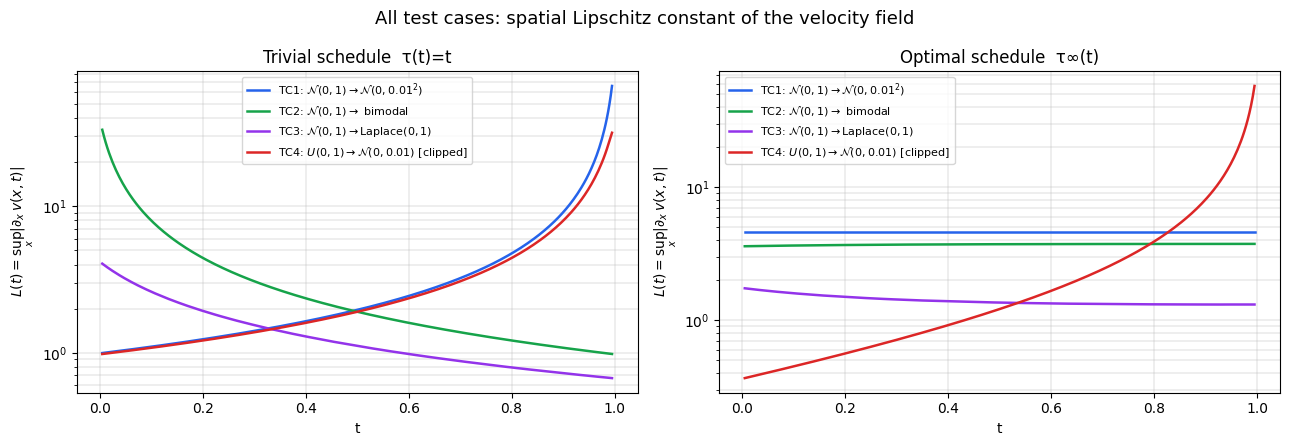

: 

: 

: 

In [ ]:
"""Overlay Lipschitz curves for all four test cases on a single log plot."""
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

t_grids = [t_lip, t_lip_tc2, t_lip_tc3, t_lip_tc4]
labels  = [
    r"TC1: $\mathcal{N}(0,1)\to\mathcal{N}(0,0.01^2)$",
    r"TC2: $\mathcal{N}(0,1)\to$ bimodal",
    r"TC3: $\mathcal{N}(0,1)\to\mathrm{Laplace}(0,1)$",
    r"TC4: $U(0,1)\to\mathcal{N}(0,0.01)$ [clipped]",
]
L_trivs = [L_triv, L_triv_tc2, L_triv_tc3, L_triv_tc4]
L_opts  = [L_opt,  L_opt_tc2,  L_opt_tc3,  L_opt_tc4]
colors  = ["#2563EB", "#16A34A", "#9333EA", "#DC2626"]

for ax, (L_t_list, title_suffix) in zip(
    axes,
    [(L_trivs, "Trivial schedule  τ(t)=t"), (L_opts, "Optimal schedule  τ∞(t)")]
):
    for tg, Lt, lbl, col in zip(t_grids, L_t_list, labels, colors):
        ax.semilogy(tg, Lt, lw=1.8, label=lbl, color=col)
    ax.set_xlabel("t")
    ax.set_ylabel(r"$L(t) = \sup_x |\partial_x v(x,t)|$")
    ax.set_title(title_suffix)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", lw=0.3)

fig.suptitle("All test cases: spatial Lipschitz constant of the velocity field", fontsize=13)
plt.tight_layout()
plt.show()